In [47]:
import random
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [48]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1,random_state=42)

In [49]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0


In [50]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [51]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy()
  new_df['target'] = df['target']
  return new_df

In [52]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [53]:
sample_features(df,0.5)

,col5,col1,target
0,1.030284,1.053909,0
1,0.778528,3.243492,1
2,-0.376825,0.712446,0
3,-2.081063,1.388329,1
4,2.110329,2.394647,0
...,...,...,...
95,-2.120719,-1.248360,1
96,0.261032,0.767628,0
97,0.990950,-0.224389,0
98,-0.665564,3.238631,1


In [72]:
#Done for combined sampling only , we can do with row sampling and feature sampling

In [54]:
df1 = combined_sampling(df,0.5,0.5)

In [55]:
df2 = combined_sampling(df,0.5,0.5)

In [56]:
df3 = combined_sampling(df,0.5,0.5)

In [57]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col4', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')
Index(['col1', 'col3', 'target'], dtype='object')


In [58]:
df1.shape

(50, 3)

In [59]:
df2.shape

(50, 3)

In [60]:
df3.shape

(50, 3)

In [61]:
df3

,col1,col3,target
96,0.767628,2.172052,0
12,3.222211,2.703011,1
46,3.201153,1.130192,1
16,2.209021,-0.251974,1
45,0.203697,0.327978,0
16,2.209021,-0.251974,1
83,2.401629,-1.157465,1
60,0.371916,1.772235,0
16,2.209021,-0.251974,1
99,0.049562,1.188431,1


In [62]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [63]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [64]:
from sklearn.tree import plot_tree

[Text(0.6, 0.9166666666666666, 'x[0] <= 0.068\ngini = 0.471\nsamples = 50\nvalue = [31, 19]'),
 Text(0.4, 0.75, 'x[1] <= 0.314\ngini = 0.397\nsamples = 22\nvalue = [6, 16]'),
 Text(0.5, 0.8333333333333333, 'True  '),
 Text(0.3, 0.5833333333333334, 'x[0] <= -0.608\ngini = 0.444\nsamples = 9\nvalue = [6, 3]'),
 Text(0.2, 0.4166666666666667, 'x[0] <= -2.195\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.1, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.5, 0.5833333333333334, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.8, 0.75, 'x[0] <= 0.802\ngini = 0.191\nsamples = 28\nvalue = [25, 3]'),
 Text(0.7, 0.8333333333333333, '  False'),
 Text(0.7, 0.5833333333333334, 'x[0] <= 0.774\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.6, 0.4166666666666667, 'x[0] <= 0.399\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.5, 0.25,

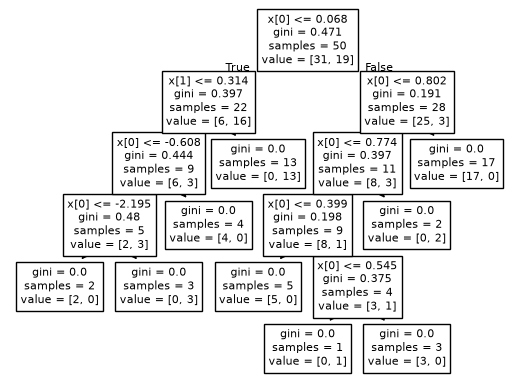

In [65]:
plot_tree(clf1)

[Text(0.45454545454545453, 0.9285714285714286, 'x[0] <= -0.213\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2727272727272727, 0.7857142857142857, 'x[1] <= 0.295\ngini = 0.087\nsamples = 22\nvalue = [21, 1]'),
 Text(0.36363636363636365, 0.8571428571428572, 'True  '),
 Text(0.18181818181818182, 0.6428571428571429, 'x[1] <= 0.247\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.09090909090909091, 0.5, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.2727272727272727, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.36363636363636365, 0.6428571428571429, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.6363636363636364, 0.7857142857142857, 'x[0] <= 1.509\ngini = 0.245\nsamples = 28\nvalue = [4, 24]'),
 Text(0.5454545454545454, 0.8571428571428572, '  False'),
 Text(0.5454545454545454, 0.6428571428571429, 'x[1] <= -0.697\ngini = 0.408\nsamples = 14\nvalue = [4, 10]'),
 Text(0.45454545454545453, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.63636363636

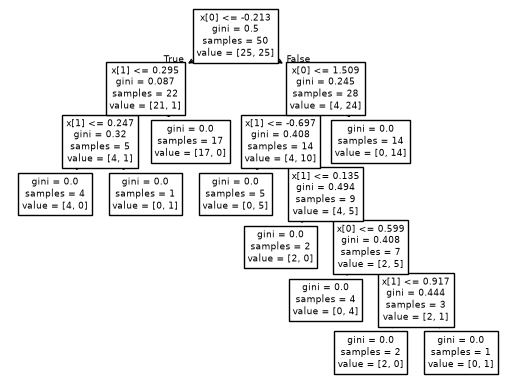

In [66]:
plot_tree(clf2)

[Text(0.6071428571428571, 0.9166666666666666, 'x[1] <= 0.973\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.35714285714285715, 0.75, 'x[1] <= 0.323\ngini = 0.444\nsamples = 24\nvalue = [16, 8]'),
 Text(0.4821428571428571, 0.8333333333333333, 'True  '),
 Text(0.2857142857142857, 0.5833333333333334, 'x[1] <= -0.265\ngini = 0.5\nsamples = 16\nvalue = [8, 8]'),
 Text(0.14285714285714285, 0.4166666666666667, 'x[1] <= -1.14\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.07142857142857142, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.21428571428571427, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.42857142857142855, 0.4166666666666667, 'x[0] <= -0.268\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.35714285714285715, 0.25, 'x[1] <= 0.11\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2857142857142857, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.42857142857142855, 0.08333333333333333, 'gini = 0.0\nsamples = 

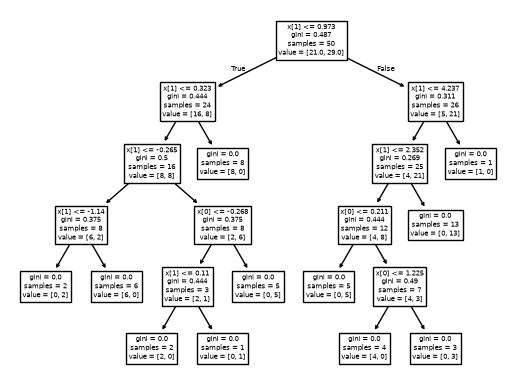

In [67]:
plot_tree(clf3)

In [68]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [69]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [70]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [71]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
66,2.209045,1.993873,1.608843,0.481608,0.319580,1
12,3.222211,1.531580,2.703011,-0.853584,-0.140891,1
82,3.066922,2.623736,2.720047,-0.397211,0.330352,1
54,-0.325418,-1.946916,-0.244625,2.670414,1.428725,0
52,-0.980984,1.337831,3.260420,2.028970,-2.302635,1
49,2.392161,1.847942,3.172198,-0.129437,0.514447,1
38,0.349650,0.515290,0.363272,1.447790,-1.120442,1
90,0.920540,-2.474934,-0.278519,2.981028,2.769344,0
58,0.300321,-0.930015,2.232421,0.162936,-0.576956,0
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
